# BÀI THỰC HÀNH 2: MẠNG NEURAL TÍCH CHẬP

<b>Hướng dẫn nộp bài:</b> Các bạn commit và push code lên github, sử dụng file txt đặt tên theo cú pháp <MSSV>.txt chứa đường link dẫn đến github của bài thực hành và nộp file txt này tên courses..

Bộ dữ liệu sử dụng: [VinaFood21 dataset](https://arxiv.org/abs/2108.02929).

Link download: https://drive.google.com/file/d/1UpZOf0XlwvB4rKpyZ35iwTA8oWHqDBbR/view?usp=share_link.

### Import libraries

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, Dense, Flatten, Concatenate, Input, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

C:\Users\PC\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

### Load data

In [6]:
# Load dữ liệu, chuẩn hóa (normalize) và reshape
INPUT_SHAPE = (28, 28)
BATCH_SIZE = 32

train = ImageDataGenerator(rescale=1./255, validation_split=0.2).flow_from_directory(
    'vinafood21/train',
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val = ImageDataGenerator(rescale=1./255, validation_split=0.2).flow_from_directory(
    'vinafood21/train',
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'vinafood21/test',
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8051 images belonging to 21 classes.
Found 2003 images belonging to 21 classes.
Found 6683 images belonging to 21 classes.


* rescale=1./25(Normalization) giúp quá trình tối ưu hóa (Optimizer) hội tụ nhanh và ổn định hơn.
* target_size=(28,28): đảm bảo mô hình LeNet hoạt động ổn định, khớp với code và đơn giản hóa quá trình tiền xử lý dữ liệu. 
* Chia tập train thành train set và val set theo tỉ lệ 80/20, để đánh giá hiệu suất của mô hình sau mỗi epoch, ngăn chặn overfitting sớm. 
* shuffle=False cho test: đảm bảo các dự đoán trên tập test sẽ luôn được tạo ra với cùng một thứ tự và kết quả đầu ra.

### Visualization

In [9]:
# Tổng quan về dataset
total_train_images = train.samples
total_val_images = val.samples
total_test_images = test.samples
NUM_CLASSES = train.num_classes

print(f"Số lượng ảnh trong tập train: {total_train_images}")
print(f"Số lượng ảnh trong tập train: {total_val_images}")
print(f"Số lượng ảnh trong tập test: {total_test_images}")
print(f"Số lượng lớp: {NUM_CLASSES}")

Số lượng ảnh trong tập train: 8051
Số lượng ảnh trong tập train: 2003
Số lượng ảnh trong tập test: 6683
Số lượng lớp: 21


In [10]:
# Thống kê nhãn trong tập train/val/test
def get_label_counts(generator):
    label_map = {v: k for k, v in generator.class_indices.items()}
    class_labels = generator.classes
    unique, counts = np.unique(class_labels, return_counts=True)
    
    counts_dict = {label_map[idx]: count for idx, count in zip(unique, counts)}
    df = pd.DataFrame(counts_dict.items(), columns=['label', 'counts'])
    
    return df

In [11]:
train_label_counts = get_label_counts(train)
train_label_counts

,label,counts
0,banh-can,291
1,banh-hoi,731
2,banh-mi-chao,348
3,banh-tet,439
4,banh-trang-tron,372
5,banh-u,213
6,banh-uot,673
7,bap-nuong,172
8,bo-kho,408
9,bo-la-lot,552


In [12]:
val_label_counts = get_label_counts(val)
val_label_counts 

,label,counts
0,banh-can,72
1,banh-hoi,182
2,banh-mi-chao,86
3,banh-tet,109
4,banh-trang-tron,93
5,banh-u,53
6,banh-uot,168
7,bap-nuong,43
8,bo-kho,101
9,bo-la-lot,137


In [13]:
test_label_counts = get_label_counts(test)
test_label_counts

,label,counts
0,banh-can,241
1,banh-hoi,607
2,banh-mi-chao,289
3,banh-tet,364
4,banh-trang-tron,309
5,banh-u,176
6,banh-uot,561
7,bap-nuong,143
8,bo-kho,338
9,bo-la-lot,458


In [14]:
train_label_counts = train_label_counts.sort_values(by='counts', ascending=False)

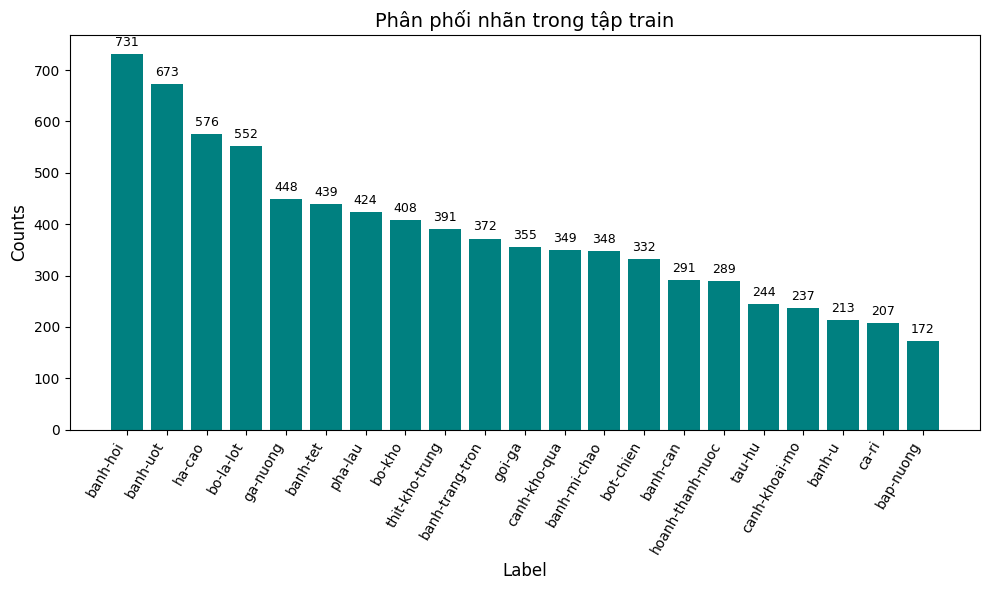

In [15]:
# Vẽ biểu đồ cột thể hiện phân bố nhãn trong tập train
plt.figure(figsize=(10, 6))
plt.bar(train_label_counts['label'], train_label_counts['counts'], color='teal')
plt.title('Phân phối nhãn trong tập train', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.xticks(rotation=60, ha='right')

for i, count in enumerate(train_label_counts['counts']):
    plt.text(i, count + 10, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

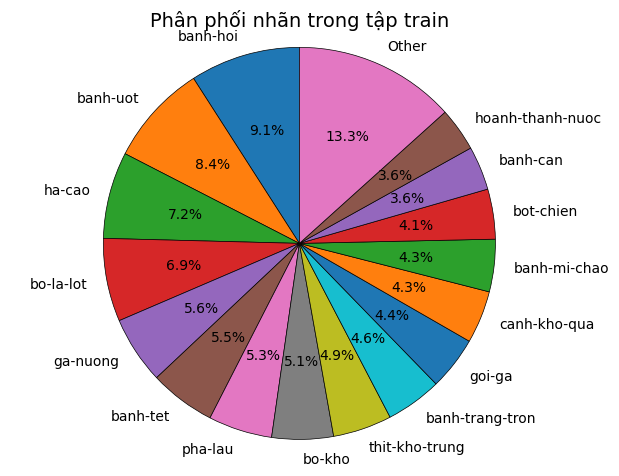

In [16]:
# Vẽ biểu đồ tròn thể hiện phân bố nhãn trong tập train
top_n = 16 # Chọn top 16 để vẽ còn lại gộp vào other
top_labels = train_label_counts['label'][:top_n]
top_counts = train_label_counts['counts'][:top_n]
    
other_count = sum(train_label_counts['counts'][top_n:])
if other_count > 0:
    top_labels = np.append(top_labels, 'Other')
    top_counts = np.append(top_counts, other_count)
    
pie_labels = top_labels
pie_counts = top_counts

plt.pie(
    pie_counts,
    labels=pie_labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
    textprops={'fontsize': 10}
)
plt.title('Phân phối nhãn trong tập train', fontsize=14)
plt.axis('equal')

plt.tight_layout()
plt.show()

# Hiển thị một vài mẫu ảnh

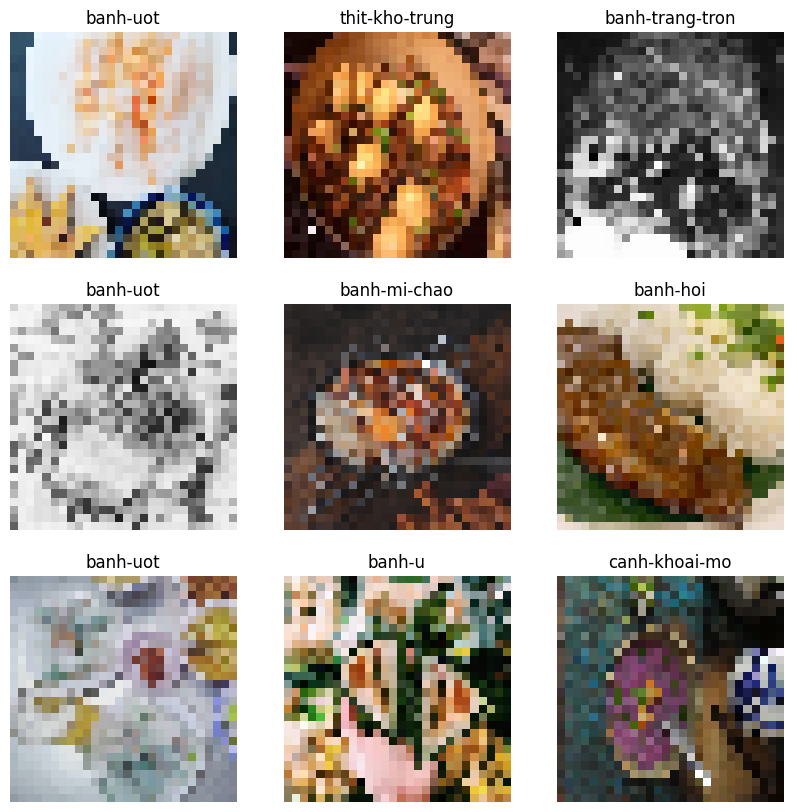

In [18]:
plt.figure(figsize=(10, 10))
class_names = list(train.class_indices.keys())
image, label = next(train)

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image[i])
    class_index = np.argmax(label[i])
    plt.title(class_names[class_index])
    plt.axis("off")
plt.show()

### Bài 1: Xây dựng mô hình LeNet. Huấn luyện và đánh giá mô hình LeNet trên 4 độ đo precision, recall và F1-macro (sử dụng Adam làm optimizer).

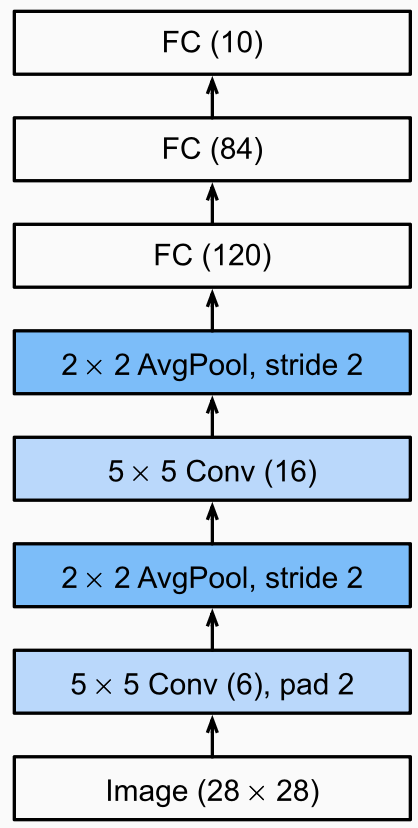

In [20]:
lenet = Sequential([
    # Conv2D(filters=6)
    Conv2D(filters=6, kernel_size=(5,5), padding='same', 
           activation='relu', 
           input_shape=(INPUT_SHAPE[0], INPUT_SHAPE[1], 3)),
    
    # Average Pooling
    AveragePooling2D(pool_size=(2,2), strides=2),

    # Conv2D(filters=16)
    Conv2D(filters=16, kernel_size=(5,5), padding='valid', activation='relu'),
    
    # Average Pooling
    AveragePooling2D(pool_size=(2,2), strides=2),

    # Flatten
    Flatten(),
    
    # Dense(120)
    Dense(120, activation='relu'),
    
    # Dense(84)
    Dense(84, activation='relu'),
    
    # Dense(NUM_CLASSES)
    Dense(NUM_CLASSES, activation='softmax')
])

C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
lenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 6)           │             456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 21)                  │           1,785 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,941 (245.86 KB)

 Trainable params: 62,941 (245.86 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Biên dịch mô hình
lenet.compile(
    optimizer=Adam(learning_rate=0.001), # Sử dụng Adam optimizer
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Định nghĩa EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

EPOCHS = 10

* LR lý tưởng thường nằm trong khoảng từ 0.001 đến 0.0001. Nếu LR quá cao, mô hình sẽ dao động, không hội tụ và có thể bỏ qua điểm tối ưu; nếu LR quá thấp quá trình học sẽ chậm và có nguy cơ bị kẹt trong các điểm tối tiểu cục bộ.
* 0.001 là giá trị LR đã được kiểm chứng cho Adam optimizer, cung cấp sự cân bằng tối ưu giữa tốc độ huấn luyện và độ tin cậy hội tụ.
* EarlyStopping theo dõi val_loss trên tập Validation, dừng lại sớm quá trình huấn luyện khi độ đo ngừng cải thiện sau 5 epoch, ngăn chặn Overfitting và tối ưu hóa tài nguyên.

In [24]:
# Huấn luyện mô hình
history = lenet.fit(
    train,
    epochs=EPOCHS,
    validation_data=val,
    callbacks=[early_stopping]
)

C:\Users\PC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
160/252 ━━━━━━━━━━━━━━━━━━━━ 1:09 754ms/step - accuracy: 0.0895 - loss: 2.9634

C:\Users\PC\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


252/252 ━━━━━━━━━━━━━━━━━━━━ 242s 955ms/step - accuracy: 0.1292 - loss: 2.8460 - val_accuracy: 0.1747 - val_loss: 2.8405
Epoch 2/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 235s 935ms/step - accuracy: 0.1892 - loss: 2.6789 - val_accuracy: 0.1697 - val_loss: 2.8196
Epoch 3/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.2032 - loss: 2.6124 - val_accuracy: 0.1722 - val_loss: 2.8035
Epoch 4/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.2218 - loss: 2.5519 - val_accuracy: 0.1598 - val_loss: 2.8327
Epoch 5/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.2369 - loss: 2.4953 - val_accuracy: 0.1857 - val_loss: 2.8345
Epoch 6/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - accuracy: 0.2638 - loss: 2.4246 - val_accuracy: 0.1982 - val_loss: 2.7300
Epoch 7/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 366s 1s/step - accuracy: 0.2703 - loss: 2.3546 - val_accuracy: 0.1947 - val_loss: 2.7762
Epoch 8/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.2903 - loss: 2.2873 - val_accuracy:

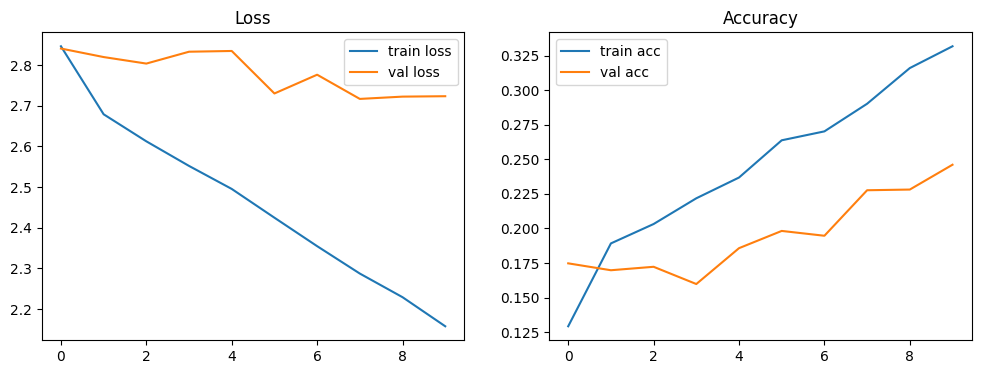

In [25]:
# Plot kết quả (accuracy và loss)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [26]:
# Đánh giá trên tập test
loss, acc = lenet.evaluate(test, verbose=0)
test.reset()
Y_pred = lenet.predict(test)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test.classes 
class_names = list(test.class_indices.keys())

209/209 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step 


In [27]:
# Báo cáo phân loại
report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Macro Avg): {report['macro avg']['precision']:.4f}")
print(f"Recall (Macro Avg): {report['macro avg']['recall']:.4f}")
print(f"F1-score (Macro Avg): {report['macro avg']['f1-score']:.4f}")

print(classification_report(y_true, y_pred_classes, target_names=class_names))

Loss: 2.5508
Accuracy: 0.2288
Precision (Macro Avg): 0.2349
Recall (Macro Avg): 0.2096
F1-score (Macro Avg): 0.1989
                  precision    recall  f1-score   support

        banh-can       0.11      0.11      0.11       241
        banh-hoi       0.31      0.27      0.29       607
    banh-mi-chao       0.18      0.44      0.26       289
        banh-tet       0.19      0.10      0.13       364
 banh-trang-tron       0.12      0.03      0.04       309
          banh-u       0.20      0.01      0.02       176
        banh-uot       0.21      0.25      0.23       561
       bap-nuong       0.14      0.01      0.01       143
          bo-kho       0.18      0.22      0.19       338
       bo-la-lot       0.40      0.60      0.48       458
       bot-chien       0.08      0.20      0.11       276
           ca-ri       0.25      0.08      0.12       171
    canh-kho-qua       0.43      0.37      0.40       290
   canh-khoai-mo       0.54      0.32      0.40       198
        ga-nu

* Kết quả huấn luyện mô hình LeNet cho bộ dữ liệu Vinafood21 đã cho thấy kiến trúc này hoàn toàn không phù hợp cho các tác vụ phân loại ảnh phức tạp hiện đại, với val_accuracy chỉ đạt mức tối đa khoảng $0.2461$ sau 10 Epoch, trong khi độ chính xác huấn luyện chỉ nhỉnh hơn một chút ở mức $0.3319%$, và chỉ số Macro F1-score tổng thể chỉ đạt $0.2$.
* Nguyên nhân chính là do sự không phù hợp về khả năng biểu diễn của kiến trúc LeNet, vốn được thiết kế cho các tác vụ đơn giản như phân loại chữ số đơn sắc (MNIST), với bộ dữ liệu Vinafood21 - dữ liệu thực tế hơn với ảnh 3 kênh màu và độ phức tạp cao, nhiều lớp và đặc trưng phức tạp hơn chữ số. LeNet có độ sâu thấp, không đủ để trích xuất các đặc trưng phân cấp phức tạp cần thiết cho việc phân loại ảnh thực phẩm.
* Giải pháp: sử dụng các mô hình học sâu hiện đại, có khả năng biểu diễn mạnh mẽ hơn và sâu hơn, kết hợp với các kĩ thuật Image Augmentation để tăng cường kích thước và sự đa dạng của tập dữ liệu huấn luyện bằng cách tạo ra các biến thể của ảnh gốc, giúp mô hình học được các đặc trưng mạnh mẽ hơn và có khả năng tổng quát hóa tốt hơn. 